## 练习1

             mean    std
species                 
Adelie     3700.7  458.6
Chinstrap  3733.1  384.3
Gentoo     5076.0  504.1


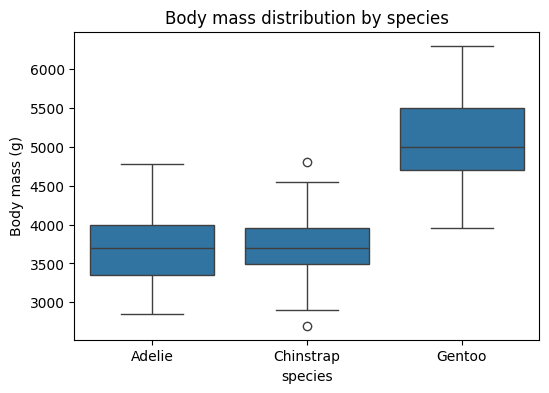

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("penguins.csv")

# 计算每个物种的体重均值和标准差
stats = df.groupby("species")["body_mass_g"].agg(["mean", "std"]).round(1)
print(stats)

# 箱线图
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="species", y="body_mass_g")
plt.title("Body mass distribution by species")
plt.ylabel("Body mass (g)")
plt.show()

## 练习2

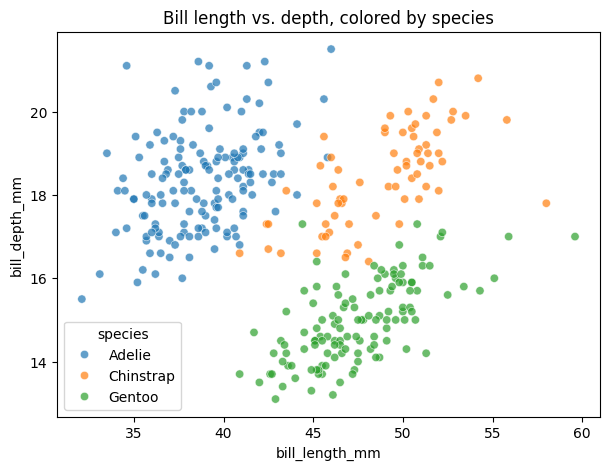

In [3]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", alpha=0.7)
plt.title("Bill length vs. depth, colored by species")
plt.show()

## 练习3

In [4]:
# 频数交叉表
ct = pd.crosstab(df["species"], df["island"])
print("Counts:\n", ct)

# 行百分比（每种物种在各岛屿的比例）
ct_pct = pd.crosstab(df["species"], df["island"], normalize="index").round(3) * 100
print("\nRow percentages (%):\n", ct_pct)

# 找出只包含一种物种的岛屿
print("\nIslands with only one species:")
for island in df["island"].unique():
    species_on_island = df[df["island"] == island]["species"].unique()
    if len(species_on_island) == 1:
        print(f"  {island}: {species_on_island[0]}")

Counts:
 island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0

Row percentages (%):
 island     Biscoe  Dream  Torgersen
species                            
Adelie       28.9   36.8       34.2
Chinstrap     0.0  100.0        0.0
Gentoo      100.0    0.0        0.0

Islands with only one species:
  Torgersen: Adelie


Torgersen 岛只有 Adelie 企鹅；Biscoe 岛有 Adelie 和 Gentoo；Dream 岛有 Adelie 和 Chinstrap。因此 Torgersen 是唯一只有一种物种的岛屿。

## 练习4

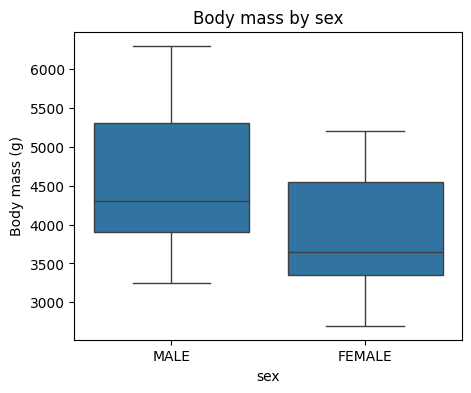

sex
FEMALE    3862.3
MALE      4545.7
Name: body_mass_g, dtype: float64


In [5]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="sex", y="body_mass_g")
plt.title("Body mass by sex")
plt.ylabel("Body mass (g)")
plt.show()

# 也可计算均值确认
print(df.groupby("sex")["body_mass_g"].mean().round(1))

雄性企鹅的体重明显高于雌性，箱线图中雄性的中位数和四分位数范围都在雌性之上。

## 练习5

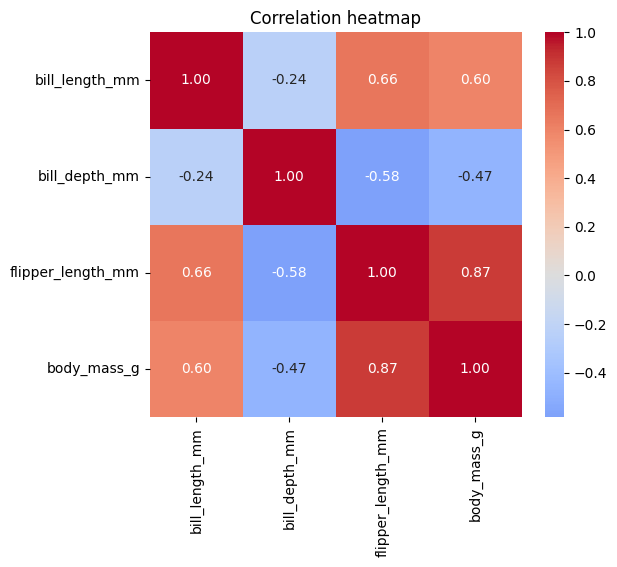

Strongest correlation: ('flipper_length_mm', 'body_mass_g') value: 0.871

Overall correlation: -0.235
Within-species correlations:
species
Adelie       0.391
Chinstrap    0.654
Gentoo       0.643
dtype: float64


In [6]:
# 热力图
corr = df.select_dtypes("number").corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

# 最强关系
strongest = corr.unstack().sort_values(ascending=False)
# 去掉自相关
strongest = strongest[strongest < 0.999]
print("Strongest correlation:", strongest.idxmax(), "value:", strongest.max().round(3))

# 喙长 vs 喙深：整体 vs 分组
overall_corr = df["bill_length_mm"].corr(df["bill_depth_mm"])
print(f"\nOverall correlation: {overall_corr:.3f}")
print("Within-species correlations:")
print(df.groupby("species")[["bill_length_mm", "bill_depth_mm"]].apply(
    lambda g: g["bill_length_mm"].corr(g["bill_depth_mm"])
).round(3))

单个相关系数 -0.235 表示整体上喙长和喙深呈弱负相关。但这个值不能诚实地总结关系，因为它掩盖了每个物种内部的正相关。如果不考虑物种，就会得出错误的结论。这正是辛普森悖论的核心：忽略潜伏变量会扭曲关系的方向和强度。

## 练习6

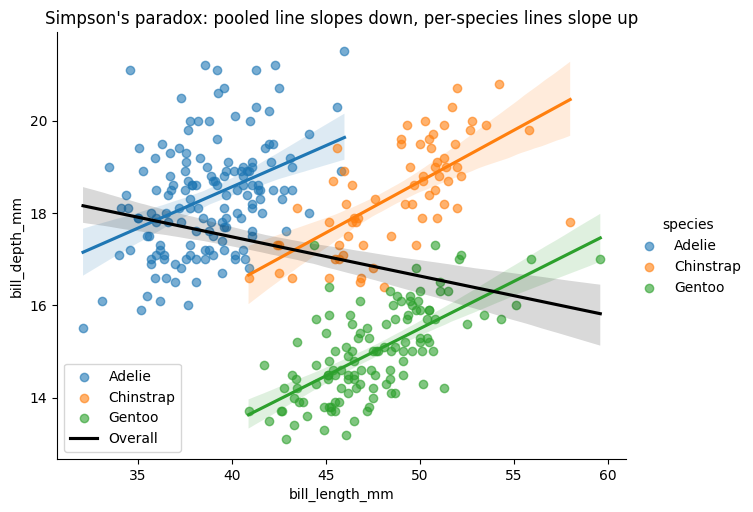

In [7]:
# 按物种的回归线（散点+线）
g = sns.lmplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species",
               height=5, aspect=1.3, scatter_kws={"alpha": 0.6})

# 叠加整体回归线（仅线条，不加点）
sns.regplot(data=df, x="bill_length_mm", y="bill_depth_mm", scatter=False,
            color="black", label="Overall", ax=g.ax)

# 添加图例和标题
g.ax.legend()
g.ax.set_title("Simpson's paradox: pooled line slopes down, per-species lines slope up")
plt.show()

整体回归线向下倾斜（负斜率），而每个物种内部的回归线向上倾斜（正斜率）。整体回归线向下倾斜（负斜率），而每个物种内部的回归线向上倾斜（正斜率）。